In [6]:
from collections import defaultdict

import pandas as pd
pd.options.display.float_format = '{:>5.2f}'.format
import numpy as np

import matplotlib.pyplot as plt
import json
from pprint import pprint

from scipy.ndimage.filters import gaussian_filter1d

In [7]:
filename = "log/output.log"
metrics = ['mrr', 'hit1', 'hit3', 'hit10']

Conjunction_queries = ['1p', '2p', '3p', '2i', '3i', 'ip', 'pi']
Negation_queries = ['2in', '3in', 'inp', 'pin', 'pni']
Disjunction_queries = ['2u', 'up', '2u-dnf', 'up-dnf']
queries = Conjunction_queries + Negation_queries + Disjunction_queries

filter_width = .1

In [8]:
def read_log_lines(filename):
    lines = []
    with open(filename, 'rt') as f:
        for line in f.readlines():
            lines.append(line)
    return lines

def filter_lines(lines, key_str):
    rec = []
    for line in lines:
        if not key_str in line:
            continue
        json_content = json.loads(line.split(']')[-1])
        try:
            rec.append(
                json_content
            )
        except:
            print("Error in ", line)
    return rec 

In [9]:
def plot_train_lines():
    rec = filter_lines(lines=lines, key_str="train upper bound noisy")
    if not rec:
        return
    data = defaultdict(list)
    for i, this_record in enumerate(rec):
        for k in this_record:
            data[k].append(this_record[k])
        data['id'].append(i)
    df = pd.DataFrame(data)

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

    ax1.set_xlabel('steps')
    ax1.set_ylabel('truth value')

    keys = ['pos_tv', 'neg_tv', 'tv']
    for label in keys:
        ax1.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
    # ax1.plot(df['id'], gaussian_filter1d(df['pos_tv'] - df['neg_tv'], filter_width), label='pos - neg', color='purple', alpha=0.5)
    ax1.axhline(y=0.5, color='r', linestyle='-')
    ax1.legend()
    # ax1.set_yscale('log')


    ax2.set_xlabel('steps')
    ax2.set_ylabel('loss')

    keys = ['pos_nll', 'neg_nll', 'loss', 'acc_loss']
    for label in keys:
        ax2.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
        
    acc_loss = []
    ax2.legend()
    ax2.set_yscale('log')
    # ax2.set_yticks([1e-2, 1e-1, 1])
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()


def plot_evaluation():
    for k in queries:
        rec = filter_lines(lines=lines, key_str=f"test epoch")
        if k not in rec[0]:
            continue
        
        fig, axes = plt.subplots(ncols=3, figsize=(7, 3))

        for ax, desc in zip(axes, ['train', 'validate', 'test']):
            rec = filter_lines(lines=lines, key_str=f"{desc} epoch")
            if not rec: continue
            data = defaultdict(list)
            for i, this_record in enumerate(rec):
                for k1 in this_record[k]:
                    data[k1].append(this_record[k][k1])
                data['id'].append(i)

            df = pd.DataFrame(data)

            ax.set_xlabel('epoch')
            ax.set_ylabel('score')
            ax.set_title(f'{desc} scores for query {k}')

            for label in metrics:
                if len(df['id']) == 1:
                    ax.scatter(df['id'], df[label] * 100, label=label)
                else:
                    ax.plot(df['id'], df[label] * 100, label=label)
            ax.legend()
            # ax.set_ylim([0, 1])

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()

In [10]:
def evaluation_to_tables(line, verbose=True):
    data = defaultdict(list)
    data['metric'] = metrics
    for m in metrics:
        for k in queries:
            if k in line:
                data[k].append(line[k][m] * 100)
    df = pd.DataFrame(data)
    try:
        df['Conjunction mean'] = df[Conjunction_queries].mean(axis=1)
    except:
        pass
    try:
        df['Negation mean'] = df[Negation_queries].mean(axis=1)
    except:
        pass
    try:
        df['Disjunction mean'] = df[Disjunction_queries].mean(axis=1)
    except:
        pass
    
    return df



\begin{tabular}{lrrrrr}
\toprule
{} &   2in &   3in &   inp &   pin &   pni \\
\midrule
0 &  0.02 &  0.01 &  0.76 &  0.03 &  2.38 \\
1 &  0.00 &  0.00 &  0.28 &  0.01 &  0.67 \\
2 &  0.01 &  0.00 &  0.57 &  0.01 &  1.94 \\
3 &  0.03 &  0.01 &  1.33 &  0.06 &  5.00 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrr}
\toprule
{} &   2in &   3in &   inp &   pin &   pni \\
\midrule
0 &  0.05 &  0.01 &  0.74 &  0.06 &  3.18 \\
1 &  0.02 &  0.00 &  0.22 &  0.03 &  1.29 \\
2 &  0.04 &  0.00 &  0.52 &  0.04 &  2.70 \\
3 &  0.09 &  0.01 &  1.44 &  0.06 &  6.24 \\
\bottomrule
\end{tabular}

==========Validation==========
CQD
  metric    1p    2p    3p    2i    3i    ip    pi   2in   3in   inp   pin   pni    2u    up  2u-dnf  up-dnf  Conjunction mean  Negation mean  Disjunction mean
0    mrr 42.92  6.23  2.56 14.30 17.63  9.37 12.61  0.02  0.01  0.76  0.03  2.38 10.59  4.82   10.58    0.10             15.09           0.64              6.52
1   hit1 32.32  2.78  0.85  7.51 10.40  4.84  6.42  0.0

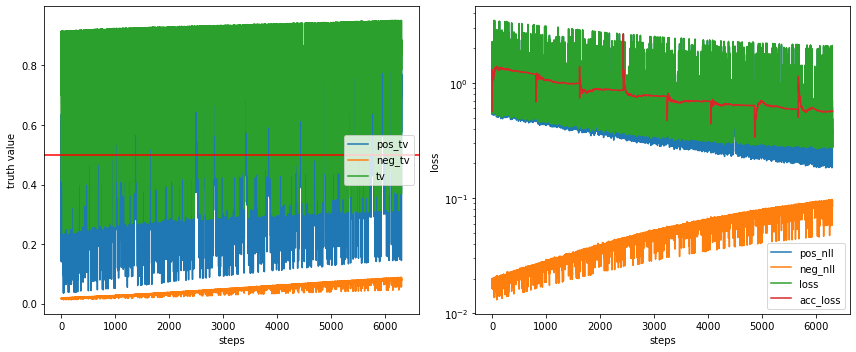

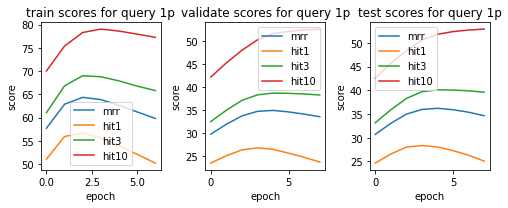

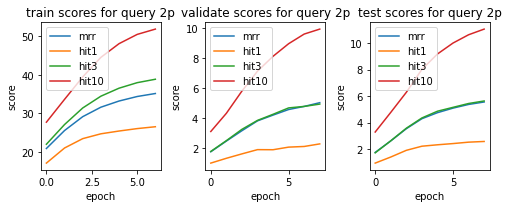

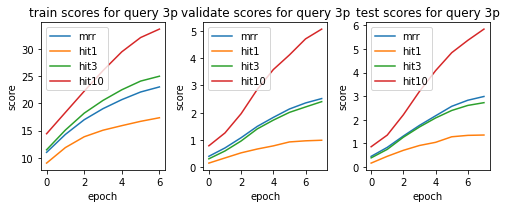

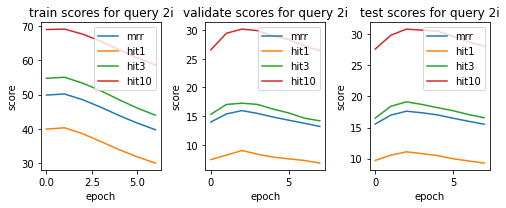

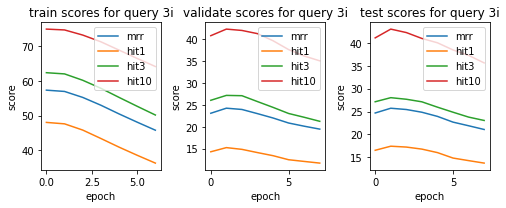

KeyError: 'ip'

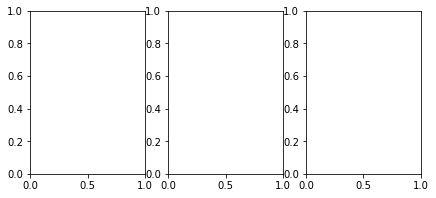

In [11]:
lines = read_log_lines(filename)


cqd_lines = filter_lines(lines, 'CQD')
print(evaluation_to_tables(cqd_lines[0])[Negation_queries].to_latex())
print(evaluation_to_tables(cqd_lines[1])[Negation_queries].to_latex())

print("=" * 10 + "Validation" + "="*10)
print("CQD")
print(evaluation_to_tables(cqd_lines[0]).to_string())


nn_lines = filter_lines(lines, 'NN valid')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"valid NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)
    
print("\n"*4)
print("=" * 10 + "test" + "="*10)
cqd_lines = filter_lines(lines, 'CQD test')
print("CQD")
print(evaluation_to_tables(cqd_lines[0]).to_string())
    
nn_lines = filter_lines(lines, 'NN test')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"test NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)
    

plot_train_lines()
plot_evaluation()

==========Validation==========
******************************
valid NN epoch 0
  metric   pin
0    mrr  0.04
1   hit1  0.00
2   hit3  0.01
3  hit10  0.05
******************************
valid NN epoch 1
  metric   pin
0    mrr  0.12
1   hit1  0.03
2   hit3  0.08
3  hit10  0.26
******************************
valid NN epoch 2
  metric   pin
0    mrr  0.36
1   hit1  0.10
2   hit3  0.28
3  hit10  0.66
******************************
valid NN epoch 3
  metric   pin
0    mrr  0.56
1   hit1  0.17
2   hit3  0.40
3  hit10  0.95
******************************
valid NN epoch 4
  metric   pin
0    mrr  0.78
1   hit1  0.21
2   hit3  0.46
3  hit10  1.54
******************************
valid NN epoch 5
  metric   pin
0    mrr  0.81
1   hit1  0.19
2   hit3  0.50
3  hit10  1.32
******************************
valid NN epoch 6
  metric   pin
0    mrr  0.97
1   hit1  0.28
2   hit3  0.64
3  hit10  1.60
******************************
valid NN epoch 7
  metric   pin
0    mrr  0.96
1   hit1  0.21
2   hit3  0.63


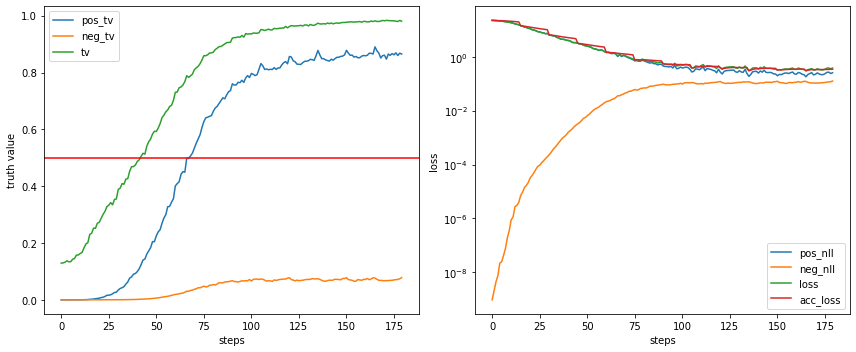

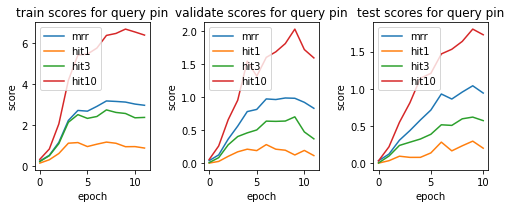

In [12]:
lines = read_log_lines('log/pin_rs1000/output.log')


# cqd_lines = filter_lines(lines, 'CQD')
# print(evaluation_to_tables(cqd_lines[0])[Negation_queries].to_latex())

print("=" * 10 + "Validation" + "="*10)
# print("CQD")
# print(evaluation_to_tables(cqd_lines[0]).to_string())


nn_lines = filter_lines(lines, 'NN valid')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"valid NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)
    
print("\n"*4)
print("=" * 10 + "test" + "="*10)

# print(evaluation_to_tables(cqd_lines[1])[Negation_queries].to_latex())
# cqd_lines = filter_lines(lines, 'CQD test')
# print("CQD")
# print(evaluation_to_tables(cqd_lines[0]).to_string())
    
nn_lines = filter_lines(lines, 'NN test')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"test NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)

     
plot_train_lines()
plot_evaluation()

==========Validation==========
******************************
valid NN epoch 0
  metric   pin
0    mrr  0.05
1   hit1  0.02
2   hit3  0.03
3  hit10  0.05
******************************
valid NN epoch 1
  metric   pin
0    mrr  0.11
1   hit1  0.02
2   hit3  0.07
3  hit10  0.24
******************************
valid NN epoch 2
  metric   pin
0    mrr  0.31
1   hit1  0.11
2   hit3  0.27
3  hit10  0.53
******************************
valid NN epoch 3
  metric   pin
0    mrr  0.44
1   hit1  0.13
2   hit3  0.38
3  hit10  0.70
******************************
valid NN epoch 4
  metric   pin
0    mrr  0.50
1   hit1  0.16
2   hit3  0.35
3  hit10  0.87
******************************
valid NN epoch 5
  metric   pin
0    mrr  0.51
1   hit1  0.14
2   hit3  0.31
3  hit10  0.91
******************************
valid NN epoch 6
  metric   pin
0    mrr  0.66
1   hit1  0.22
2   hit3  0.50
3  hit10  1.23
******************************
valid NN epoch 7
  metric   pin
0    mrr  0.63
1   hit1  0.20
2   hit3  0.46


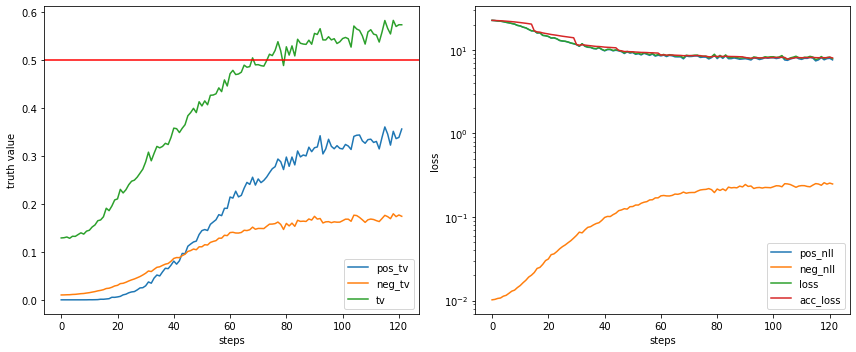

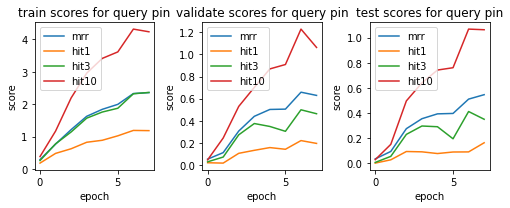

In [21]:
lines = read_log_lines('log/pin_rs1000_nss_10/output.log')


# cqd_lines = filter_lines(lines, 'CQD')
# print(evaluation_to_tables(cqd_lines[0])[Negation_queries].to_latex())

print("=" * 10 + "Validation" + "="*10)
# print("CQD")
# print(evaluation_to_tables(cqd_lines[0]).to_string())


nn_lines = filter_lines(lines, 'NN valid')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"valid NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)

    
    
print("\n"*4)
print("=" * 10 + "test" + "="*10)

# print(evaluation_to_tables(cqd_lines[1])[Negation_queries].to_latex())
# cqd_lines = filter_lines(lines, 'CQD test')
# print("CQD")
# print(evaluation_to_tables(cqd_lines[0]).to_string())
    
nn_lines = filter_lines(lines, 'NN test')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"test NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)
    
     
plot_train_lines()
plot_evaluation()

In [34]:
lines = read_log_lines('log/pin_rs1000_neg_size=32/output.log')


# cqd_lines = filter_lines(lines, 'CQD')
# print(evaluation_to_tables(cqd_lines[0])[Negation_queries].to_latex())

print("=" * 10 + "Validation" + "="*10)
# print("CQD")
# print(evaluation_to_tables(cqd_lines[0]).to_string())


nn_lines = filter_lines(lines, 'NN valid')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"valid NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)

    
    
print("\n"*4)
print("=" * 10 + "test" + "="*10)

# print(evaluation_to_tables(cqd_lines[1])[Negation_queries].to_latex())
# cqd_lines = filter_lines(lines, 'CQD test')
# print("CQD")
# print(evaluation_to_tables(cqd_lines[0]).to_string())
    
nn_lines = filter_lines(lines, 'NN test')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"test NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)
    
     
plot_train_lines()
plot_evaluation()

==========Validation==========





==========test==========


IndexError: list index out of range

==========Validation==========
******************************
valid NN epoch 0
  metric    3p
0    mrr  1.11
1   hit1  0.53
2   hit3  1.00
3  hit10  2.01
******************************
valid NN epoch 1
  metric    3p
0    mrr  2.24
1   hit1  1.00
2   hit3  2.06
3  hit10  4.37
******************************
valid NN epoch 2
  metric    3p
0    mrr  2.40
1   hit1  1.01
2   hit3  2.22
3  hit10  4.67
******************************
valid NN epoch 3
  metric    3p
0    mrr  2.39
1   hit1  0.96
2   hit3  2.09
3  hit10  4.81
******************************
valid NN epoch 4
  metric    3p
0    mrr  2.01
1   hit1  0.60
2   hit3  1.62
3  hit10  4.34
******************************
valid NN epoch 5
  metric    3p
0    mrr  1.47
1   hit1  0.29
2   hit3  0.91
3  hit10  3.24





==========test==========
******************************
test NN epoch 0
  metric    3p
0    mrr  1.40
1   hit1  0.79
2   hit3  1.39
3  hit10  2.32
******************************
test NN epoch 1
  metric    3p
0    mrr  2.80
1 

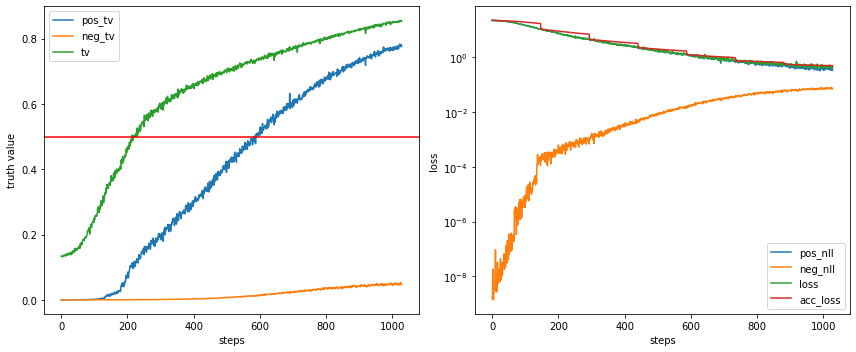

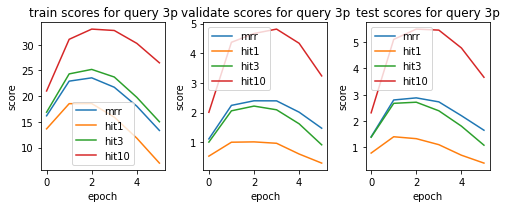

In [49]:
lines = read_log_lines('log/p3_rs1000/output.log')


# cqd_lines = filter_lines(lines, 'CQD')
# print(evaluation_to_tables(cqd_lines[0])[Negation_queries].to_latex())

print("=" * 10 + "Validation" + "="*10)
# print("CQD")
# print(evaluation_to_tables(cqd_lines[0]).to_string())


nn_lines = filter_lines(lines, 'NN valid')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"valid NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)

    
    
print("\n"*4)
print("=" * 10 + "test" + "="*10)

# print(evaluation_to_tables(cqd_lines[1])[Negation_queries].to_latex())
# cqd_lines = filter_lines(lines, 'CQD test')
# print("CQD")
# print(evaluation_to_tables(cqd_lines[0]).to_string())
    
nn_lines = filter_lines(lines, 'NN test')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"test NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)
plot_train_lines()
plot_evaluation()

==========Validation==========
******************************
valid NN epoch 0
  metric    3p
0    mrr  1.18
1   hit1  0.58
2   hit3  1.11
3  hit10  2.13
******************************
valid NN epoch 1
  metric    3p
0    mrr  2.28
1   hit1  1.02
2   hit3  2.00
3  hit10  4.48
******************************
valid NN epoch 2
  metric    3p
0    mrr  2.37
1   hit1  0.97
2   hit3  2.14
3  hit10  4.63
******************************
valid NN epoch 3
  metric    3p
0    mrr  2.38
1   hit1  0.93
2   hit3  2.15
3  hit10  4.75
******************************
valid NN epoch 4
  metric    3p
0    mrr  2.05
1   hit1  0.64
2   hit3  1.60
3  hit10  4.33
******************************
valid NN epoch 5
  metric    3p
0    mrr  1.45
1   hit1  0.23
2   hit3  1.01
3  hit10  3.33
******************************
valid NN epoch 6
  metric    3p
0    mrr  1.13
1   hit1  0.09
2   hit3  0.59
3  hit10  2.61
******************************
valid NN epoch 7
  metric    3p
0    mrr  0.97
1   hit1  0.10
2   hit3  0.42


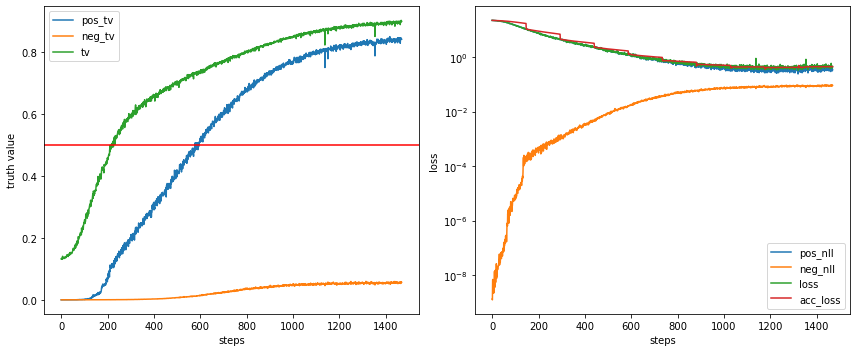

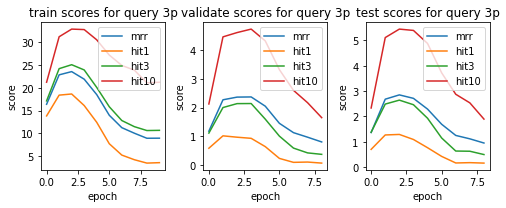

In [50]:
lines = read_log_lines('log/p3_rs1000_nss_1024/output.log')


# cqd_lines = filter_lines(lines, 'CQD')
# print(evaluation_to_tables(cqd_lines[0])[Negation_queries].to_latex())

print("=" * 10 + "Validation" + "="*10)
# print("CQD")
# print(evaluation_to_tables(cqd_lines[0]).to_string())


nn_lines = filter_lines(lines, 'NN valid')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"valid NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)

    
    
print("\n"*4)
print("=" * 10 + "test" + "="*10)

# print(evaluation_to_tables(cqd_lines[1])[Negation_queries].to_latex())
# cqd_lines = filter_lines(lines, 'CQD test')
# print("CQD")
# print(evaluation_to_tables(cqd_lines[0]).to_string())
    
nn_lines = filter_lines(lines, 'NN test')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"test NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)
plot_train_lines()
plot_evaluation()